# Vision Transformer - Fraud Type Classification - 20K Passport Dataset

**Phase 2 of the forgery detection pipeline.**

Given a document already classified as FAKE by Phase 1, this model classifies the fraud type:
- **Class 0**: face_morphing
- **Class 1**: face_replacement

## Dataset
- Filtered from 20K passport dataset to **fakes only**
- Train: ~8,000 | Val: ~1,000 | Test: ~1,000
- Countries: ALB, GRC, LVA

## Architecture

| Setting | Value |
|---------|-------|
| **Model** | ViT-Small (384-dim) |
| **Loss** | Focal Loss (gamma=2.0) |
| **Augmentation** | Light (preserve forgery artifacts) |
| **Training** | 3-stage gradual unfreezing |
| **Head** | MLP (LayerNorm -> Linear -> GELU -> Dropout -> Linear) |
| **TTA** | 4 augmented views |

## Setup

In [1]:
import os
import sys

project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/roy-siftt/final-project


In [2]:
%pip install -q timm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## Load Data (Fakes Only from 20K Passport Dataset)

In [4]:
data_dir = "/Users/roy-siftt/final-project/notebooks/passport_forgery/production/data"
dataset_root = "/Users/roy-siftt/final-project/datasets/passport_20k"

# Load full splits and filter to fakes only
fraud_type_map = {'face_morphing': 0, 'face_replacement': 1}

train_df_full = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df_full = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df_full = pd.read_csv(os.path.join(data_dir, "test.csv"))

# Filter to fakes only
train_df = train_df_full[train_df_full['is_fake'] == 1].reset_index(drop=True)
val_df = val_df_full[val_df_full['is_fake'] == 1].reset_index(drop=True)
test_df = test_df_full[test_df_full['is_fake'] == 1].reset_index(drop=True)

# Add numeric fraud type label
train_df['fraud_label'] = train_df['fraud_type'].map(fraud_type_map)
val_df['fraud_label'] = val_df['fraud_type'].map(fraud_type_map)
test_df['fraud_label'] = test_df['fraud_type'].map(fraud_type_map)

print(f"Fakes-only dataset:")
print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)}")

print(f"\nTrain balance:")
for ft, count in train_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(train_df)*100:.1f}%)")

print(f"\nVal balance:")
for ft, count in val_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(val_df)*100:.1f}%)")

print(f"\nTest balance:")
for ft, count in test_df['fraud_type'].value_counts().items():
    print(f"  {ft}: {count} ({count/len(test_df)*100:.1f}%)")

Fakes-only dataset:
  Train: 8000 | Val: 1000 | Test: 1000
  Total: 10000

Train balance:
  face_replacement: 4008 (50.1%)
  face_morphing: 3992 (49.9%)

Val balance:
  face_morphing: 519 (51.9%)
  face_replacement: 481 (48.1%)

Test balance:
  face_replacement: 512 (51.2%)
  face_morphing: 488 (48.8%)


## Focal Loss

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal Loss defined (gamma=2.0)")

Focal Loss defined (gamma=2.0)


## Lighter Augmentation Strategy

Same as binary model: preserve forgery artifacts, minimal blur/noise, NO CoarseDropout.

In [6]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=0,
        p=0.5
    ),
    A.Perspective(
        scale=(0.02, 0.05),
        p=0.2
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.1
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

tta_transforms = [
    val_test_transform,
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(0.95, 0.95), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(1.05, 1.05), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

print("Augmentation strategy:")
print("  - LIGHTER transforms to preserve forgery artifacts")
print("  - NO CoarseDropout")
print("  - Minimal blur/noise")
print("  - TTA: 4 augmented views")

Augmentation strategy:
  - LIGHTER transforms to preserve forgery artifacts
  - NO CoarseDropout
  - Minimal blur/noise
  - TTA: 4 augmented views


## Dataset Class

In [7]:
class FraudTypeDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform is not None:
            transformed = self.transform(image=img_np)
            img = transformed['image']

        label = int(row['fraud_label'])  # 0=morphing, 1=replacement
        return img, torch.tensor(label, dtype=torch.long)

# Create datasets
train_dataset = FraudTypeDataset(train_df, dataset_root, train_transform)
val_dataset = FraudTypeDataset(val_df, dataset_root, val_test_transform)
test_dataset = FraudTypeDataset(test_df, dataset_root, val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Batch size: 64")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Batch size: 64
Train batches: 125 | Val batches: 16 | Test batches: 16


## ViT-Small Model with MLP Head

In [8]:
class ViTFraudTypeClassifier(nn.Module):
    def __init__(self, model_name='vit_small_patch16_224', num_classes=2, pretrained=True, dropout=0.1):
        super(ViTFraudTypeClassifier, self).__init__()
        
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        num_features = self.vit.embed_dim
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, num_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_features // 2, num_classes)
        )
        
        print(f"Model: {model_name}")
        print(f"  - Embedding dim: {num_features}")
        print(f"  - MLP head: {num_features} -> {num_features//2} -> {num_classes}")
        print(f"  - Classes: 0=face_morphing, 1=face_replacement")
        print(f"  - Dropout: {dropout}")
        print(f"  - Total params: {sum(p.numel() for p in self.parameters()):,}")
        
    def forward(self, x):
        features = self.vit(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone FROZEN")
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")
    
    def unfreeze_last_n_blocks(self, n=4):
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        for block in self.vit.blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        for param in self.vit.norm.parameters():
            param.requires_grad = True
        print(f"Last {n} transformer blocks UNFROZEN")

# Create model
model = ViTFraudTypeClassifier(
    model_name='vit_small_patch16_224',
    num_classes=2,
    pretrained=True,
    dropout=0.1
).to(device)

Model: vit_small_patch16_224
  - Embedding dim: 384
  - MLP head: 384 -> 192 -> 2
  - Classes: 0=face_morphing, 1=face_replacement
  - Dropout: 0.1
  - Total params: 21,740,738


## Training with 3-Stage Unfreezing + OneCycleLR

1. **Stage 1 (10 epochs):** Train only classifier head
2. **Stage 2 (15 epochs):** Unfreeze last 4 transformer blocks
3. **Stage 3 (25 epochs):** Full fine-tuning with lower LR

In [9]:
criterion = FocalLoss(alpha=1.0, gamma=2.0)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = None
best_epoch = 0
max_grad_norm = 1.0

def evaluate(loader, use_tta=False):
    model.eval()
    
    if not use_tta:
        total, correct = 0, 0
        loss_total = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss_total += loss.item()
                
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return {
            'acc': correct / total,
            'loss': loss_total / len(loader),
            'preds': all_preds,
            'labels': all_labels
        }
    else:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in loader:
                batch_probs = []
                imgs_np = imgs.numpy().transpose(0, 2, 3, 1)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                imgs_np = (imgs_np * std + mean) * 255
                imgs_np = imgs_np.astype(np.uint8)
                
                for tta_transform in tta_transforms:
                    tta_imgs = []
                    for img in imgs_np:
                        transformed = tta_transform(image=img)
                        tta_imgs.append(transformed['image'])
                    tta_batch = torch.stack(tta_imgs).to(device)
                    outputs = model(tta_batch)
                    probs = F.softmax(outputs, dim=1)
                    batch_probs.append(probs.cpu())
                
                avg_probs = torch.stack(batch_probs).mean(dim=0)
                all_probs.append(avg_probs)
                all_labels.extend(labels.numpy())
        
        all_probs = torch.cat(all_probs, dim=0)
        all_preds = all_probs.argmax(dim=1).numpy()
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        
        return {
            'acc': correct / total,
            'loss': 0.0,
            'preds': all_preds.tolist(),
            'labels': all_labels.tolist()
        }

def train_one_epoch(train_loader, optimizer, scheduler, epoch_desc):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=epoch_desc)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    return total_loss / len(train_loader)

print("Training functions defined")
print(f"  - Focal Loss (gamma=2.0)")
print(f"  - TTA evaluation available")

Training functions defined
  - Focal Loss (gamma=2.0)
  - TTA evaluation available


In [10]:
# ============================================
# STAGE 1: Train Classifier Head Only
# ============================================
print("\n" + "="*70)
print("STAGE 1: Training Classifier Head (10 epochs)")
print("="*70)

model.freeze_backbone()

stage1_epochs = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer, 
    max_lr=1e-3,
    epochs=stage1_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S1 Epoch {epoch+1}/{stage1_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage1_end = len(history['train_loss'])
print(f"\nStage 1 complete. Best val acc: {best_val_acc:.4f}")


STAGE 1: Training Classifier Head (10 epochs)
Backbone FROZEN


S1 Epoch 1/10: 100%|██████████| 125/125 [01:55<00:00,  1.08it/s, loss=0.1694, lr=1.00e-03]


  Train Acc: 0.6736 | Val Acc: 0.7100 | Val Loss: 0.1450
  -> New best: 0.7100


S1 Epoch 2/10: 100%|██████████| 125/125 [02:19<00:00,  1.11s/it, loss=0.1414, lr=9.69e-04]


  Train Acc: 0.7004 | Val Acc: 0.7370 | Val Loss: 0.1336
  -> New best: 0.7370


...

  Train Acc: 0.7484 | Val Acc: 0.7910 | Val Loss: 0.1220
  -> New best: 0.7910


S1 Epoch 9/10: 100%|██████████| 125/125 [02:34<00:00,  1.23s/it, loss=0.1373, lr=2.97e-05]


  Train Acc: 0.7474 | Val Acc: 0.7910 | Val Loss: 0.1215


S1 Epoch 10/10: 100%|██████████| 125/125 [02:10<00:00,  1.05s/it, loss=0.1252, lr=5.95e-09]


  Train Acc: 0.7524 | Val Acc: 0.7970 | Val Loss: 0.1208
  -> New best: 0.7970

Stage 1 complete. Best val acc: 0.7970


In [11]:
# ============================================
# STAGE 2: Unfreeze Last 4 Transformer Blocks
# ============================================
print("\n" + "="*70)
print("STAGE 2: Unfreezing Last 4 Blocks (15 epochs)")
print("="*70)

model.unfreeze_last_n_blocks(n=4)

stage2_epochs = 15
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-5,
    epochs=stage2_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S2 Epoch {epoch+1}/{stage2_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage1_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage2_end = len(history['train_loss'])
print(f"\nStage 2 complete. Best val acc: {best_val_acc:.4f}")


STAGE 2: Unfreezing Last 4 Blocks (15 epochs)
Last 4 transformer blocks UNFROZEN


S2 Epoch 1/15: 100%|██████████| 125/125 [02:50<00:00,  1.36s/it, loss=0.1332, lr=3.82e-05]


  Train Acc: 0.7696 | Val Acc: 0.8140 | Val Loss: 0.1099
  -> New best: 0.8140


S2 Epoch 2/15: 100%|██████████| 125/125 [03:30<00:00,  1.69s/it, loss=0.1194, lr=4.98e-05]


  Train Acc: 0.8227 | Val Acc: 0.8620 | Val Loss: 0.0830
  -> New best: 0.8620


...

  Train Acc: 0.9200 | Val Acc: 0.9250 | Val Loss: 0.0503
  -> New best: 0.9250


S2 Epoch 14/15: 100%|██████████| 125/125 [02:21<00:00,  1.14s/it, loss=0.0432, lr=6.63e-07]


  Train Acc: 0.9165 | Val Acc: 0.9250 | Val Loss: 0.0494


S2 Epoch 15/15: 100%|██████████| 125/125 [04:59<00:00,  2.39s/it, loss=0.0210, lr=2.43e-10] 


  Train Acc: 0.9191 | Val Acc: 0.9240 | Val Loss: 0.0493

Stage 2 complete. Best val acc: 0.9250


In [12]:
# ============================================
# STAGE 3: Full Fine-Tuning
# ============================================
print("\n" + "="*70)
print("STAGE 3: Full Fine-Tuning (25 epochs)")
print("="*70)

model.unfreeze_backbone()

stage3_epochs = 25
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-5,
    epochs=stage3_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,
    anneal_strategy='cos'
)

patience = 8
patience_counter = 0

for epoch in range(stage3_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S3 Epoch {epoch+1}/{stage3_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage2_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc + 0.002:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {total_epoch}")
            break

print(f"\nStage 3 complete. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


STAGE 3: Full Fine-Tuning (25 epochs)
Backbone UNFROZEN


S3 Epoch 1/25: 100%|██████████| 125/125 [03:32<00:00,  1.70s/it, loss=0.0401, lr=9.13e-06]


  Train Acc: 0.9170 | Val Acc: 0.9290 | Val Loss: 0.0520
  -> New best: 0.9290


S3 Epoch 2/25: 100%|██████████| 125/125 [03:17<00:00,  1.58s/it, loss=0.0704, lr=9.97e-06]


  Train Acc: 0.9233 | Val Acc: 0.9270 | Val Loss: 0.0555


...

  Train Acc: 0.9669 | Val Acc: 0.9640 | Val Loss: 0.0326


S3 Epoch 17/25: 100%|██████████| 125/125 [02:50<00:00,  1.37s/it, loss=0.0289, lr=2.54e-06]


  Train Acc: 0.9663 | Val Acc: 0.9650 | Val Loss: 0.0305


S3 Epoch 18/25: 100%|██████████| 125/125 [02:50<00:00,  1.36s/it, loss=0.0493, lr=1.99e-06]


  Train Acc: 0.9654 | Val Acc: 0.9630 | Val Loss: 0.0374
  Early stopping at epoch 43

Stage 3 complete. Best val acc: 0.9650 at epoch 35


In [13]:
# Load best model
print("\n" + "="*70)
print("Loading Best Model")
print("="*70)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
else:
    print("Warning: No best model state saved")


Loading Best Model
Loaded best model from epoch 35
Best validation accuracy: 0.9650


## Final Evaluation

In [14]:
print("\n" + "="*70)
print("FINAL TEST EVALUATION - FRAUD TYPE")
print("="*70)

test_metrics = evaluate(test_loader, use_tta=False)
print(f"\nTest Accuracy (standard): {test_metrics['acc']:.4f}")

print("\nRunning Test-Time Augmentation (4 views)...")
test_metrics_tta = evaluate(test_loader, use_tta=True)
print(f"Test Accuracy (with TTA): {test_metrics_tta['acc']:.4f}")


FINAL TEST EVALUATION - FRAUD TYPE

Test Accuracy (standard): 0.9640

Running Test-Time Augmentation (4 views)...
Test Accuracy (with TTA): 0.9680


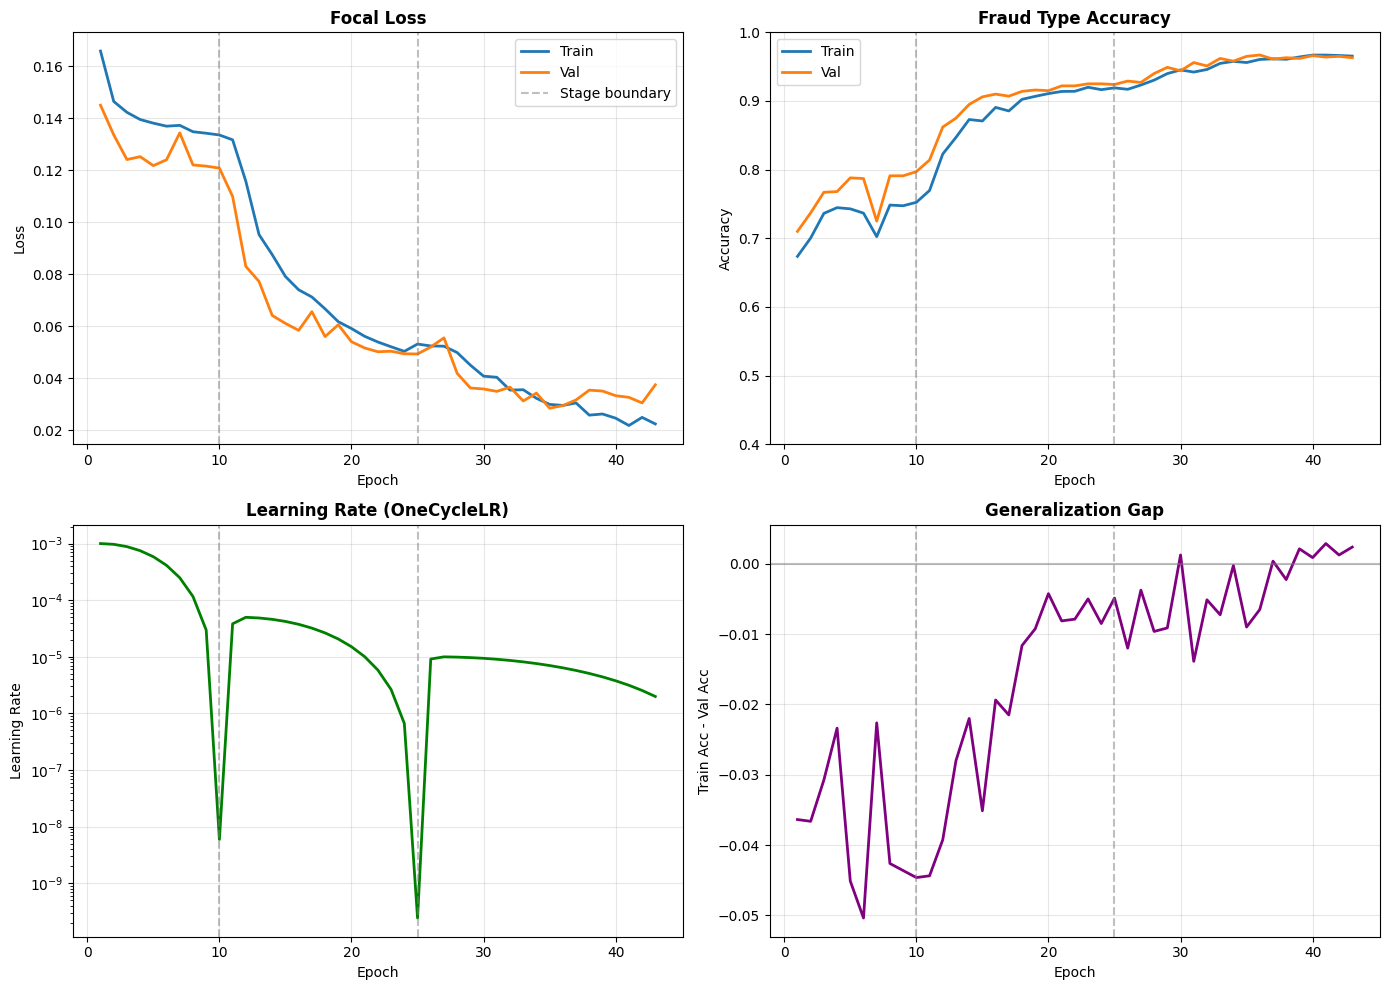

In [15]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], label='Val', linewidth=2)
axes[0, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5, label='Stage boundary')
axes[0, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Focal Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], label='Val', linewidth=2)
axes[0, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Fraud Type Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

axes[1, 0].plot(epochs, history['lr'], linewidth=2, color='green')
axes[1, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Generalization Gap', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/passport_forgery/production/training_curves_fraud_type.png', dpi=150)
plt.show()


CONFUSION MATRIX


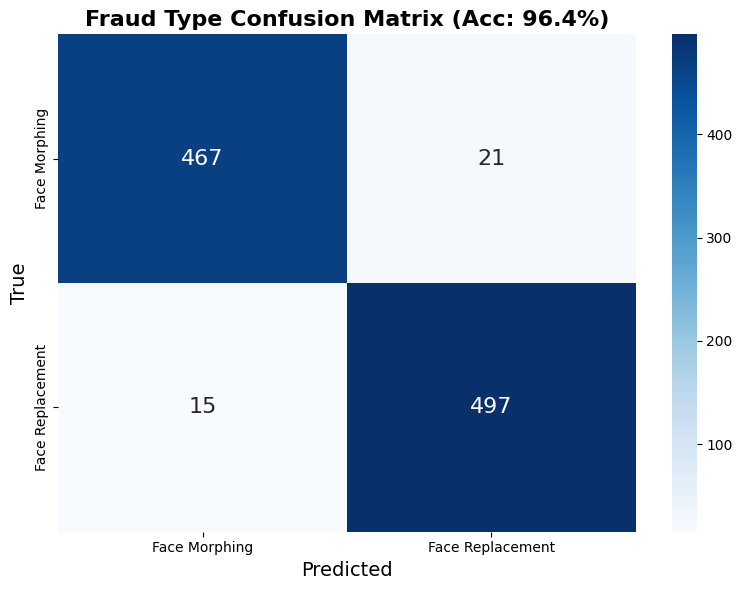


Classification Report:
                  precision    recall  f1-score   support

   Face Morphing       0.97      0.96      0.96       488
Face Replacement       0.96      0.97      0.97       512

        accuracy                           0.96      1000
       macro avg       0.96      0.96      0.96      1000
    weighted avg       0.96      0.96      0.96      1000



In [16]:
# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
labels = ['Face Morphing', 'Face Replacement']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title(f'Fraud Type Confusion Matrix (Acc: {test_metrics["acc"]*100:.1f}%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/passport_forgery/production/confusion_matrix_fraud_type.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

## Save Model

In [17]:
import pickle
import shutil

notebook_dir = "/Users/roy-siftt/final-project/notebooks/passport_forgery/production"
model_path = os.path.join(notebook_dir, "vit_fraud_type_20k.pth")

# Check disk space
disk = shutil.disk_usage(notebook_dir)
free_gb = disk.free / (1024**3)
print(f"Disk space available: {free_gb:.1f} GB")

if free_gb < 0.5:
    print("WARNING: Low disk space! Saving to /tmp/ instead")
    model_path = "/tmp/vit_fraud_type_20k.pth"

try:
    if best_model_state is not None:
        cpu_state = {k: v.cpu() for k, v in best_model_state.items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
        print(f"  Best epoch: {best_epoch}")
        print(f"  Best val acc: {best_val_acc:.4f}")
        print(f"  Test acc: {test_metrics['acc']:.4f}")
        print(f"  Test acc (TTA): {test_metrics_tta['acc']:.4f}")
    else:
        cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Save failed: {e}")
    fallback = "/tmp/vit_fraud_type_20k.pth"
    cpu_state = {k: v.cpu() for k, v in (best_model_state or model.state_dict()).items()}
    torch.save(cpu_state, fallback)
    print(f"Saved to fallback: {fallback}")

# Save training history
history_path = os.path.join(notebook_dir, "training_history_fraud_type.pkl")
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"Training history saved to: {history_path}")

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {size_mb:.1f} MB")

Disk space available: 17.3 GB
Model saved to: /Users/roy-siftt/final-project/notebooks/passport_forgery/production/vit_fraud_type_20k.pth
  Best epoch: 35
  Best val acc: 0.9650
  Test acc: 0.9640
  Test acc (TTA): 0.9680
Training history saved to: /Users/roy-siftt/final-project/notebooks/passport_forgery/production/training_history_fraud_type.pkl
Model file size: 83.0 MB


## Out-of-Dataset Evaluation (test_samples.json -- fakes only)

In [18]:
import json

# Auto-reload transforms if needed
if 'tta_transforms' not in dir():
    print("Reloading transforms...")
    tta_transforms = [
        A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(0.95, 0.95), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(1.05, 1.05), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
    ]

fraud_type_map_eval = {'face_morphing': 0, 'face_replacement': 1}
fraud_type_names = {0: 'Face Morphing', 1: 'Face Replacement'}

def predict_single(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for transform in tta_transforms:
            transformed = transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    
    avg_probs = torch.stack(all_probs).mean(dim=0)
    pred = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred].item()
    
    return pred, confidence

# Load test samples and filter to fakes only
samples_path = os.path.join(project_root, "notebooks/passport_forgery/experiments/test_samples.json")
with open(samples_path) as f:
    all_samples = json.load(f)

# Only evaluate on fake samples
samples = [s for s in all_samples if s['is_fake'] == 1]

print(f"\n{'='*70}")
print(f"OUT-OF-DATASET FRAUD TYPE EVALUATION ({len(samples)} fake samples)")
print(f"{'='*70}")
print(f"  face_morphing: {sum(1 for s in samples if s['fraud_type'] == 'face_morphing')}")
print(f"  face_replacement: {sum(1 for s in samples if s['fraud_type'] == 'face_replacement')}")

true_labels, pred_labels, details = [], [], []
skipped = 0

for s in tqdm(samples, desc="Evaluating"):
    img_path = os.path.join(project_root, s['path'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    true_idx = fraud_type_map_eval[s['fraud_type']]
    pred_idx, confidence = predict_single(img_path, model, device)
    
    pred_name = fraud_type_names[pred_idx]
    true_name = fraud_type_names[true_idx]

    true_labels.append(true_idx)
    pred_labels.append(pred_idx)
    details.append({
        'path': s['path'],
        'country': s['country'],
        'fraud_type': s['fraud_type'],
        'true': true_name,
        'pred': pred_name,
        'confidence': confidence,
        'correct': pred_idx == true_idx
    })

if skipped:
    print(f"Skipped {skipped} (file not found)")

# Results
correct = sum(d['correct'] for d in details)
total = len(details)
ood_accuracy = correct / total

print(f"\nOverall Accuracy: {ood_accuracy:.4f} ({correct}/{total})")

# Per fraud type
print(f"\nPer Fraud Type:")
for ftype in ['face_morphing', 'face_replacement']:
    subset = [d for d in details if d['fraud_type'] == ftype]
    acc = sum(d['correct'] for d in subset) / len(subset)
    avg_conf = sum(d['confidence'] for d in subset) / len(subset)
    print(f"  {ftype:20s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)}) avg conf: {avg_conf:.4f}")

# Per country (ALB, GRC, LVA)
print(f"\nPer Country:")
for country in sorted(set(d['country'] for d in details)):
    subset = [d for d in details if d['country'] == country]
    acc = sum(d['correct'] for d in subset) / len(subset)
    print(f"  {country}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Classification report
print(f"\n{'='*60}")
print(classification_report(true_labels, pred_labels, target_names=['Face Morphing', 'Face Replacement']))

# Worst mistakes
wrong = sorted([d for d in details if not d['correct']], key=lambda x: -x['confidence'])
if wrong:
    print(f"\nTop 10 most confident WRONG predictions:")
    print("-" * 80)
    for d in wrong[:10]:
        fname = d['path'].split('/')[-1]
        print(f"  {d['country']} | true={d['true']:20s} pred={d['pred']:20s} | conf={d['confidence']*100:.1f}% | {fname}")


OUT-OF-DATASET FRAUD TYPE EVALUATION (1998 fake samples)
  face_morphing: 999
  face_replacement: 999


Evaluating: 100%|██████████| 1998/1998 [01:54<00:00, 17.38it/s]


Overall Accuracy: 0.9650 (1928/1998)

Per Fraud Type:
  face_morphing       : 0.9540 (953/999) avg conf: 0.8495
  face_replacement    : 0.9760 (975/999) avg conf: 0.8920

Per Country:
  ALB: 0.9595 (639/666)
  GRC: 0.9625 (641/666)
  LVA: 0.9730 (648/666)

                  precision    recall  f1-score   support

   Face Morphing       0.98      0.95      0.96       999
Face Replacement       0.95      0.98      0.97       999

        accuracy                           0.96      1998
       macro avg       0.97      0.96      0.96      1998
    weighted avg       0.97      0.96      0.96      1998


Top 10 most confident WRONG predictions:
--------------------------------------------------------------------------------
  ALB | true=Face Morphing        pred=Face Replacement     | conf=88.8% | generated.photos_v3_0659410.png
  ALB | true=Face Morphing        pred=Face Replacement     | conf=88.4% | generated.photos_0210845.png
  GRC | true=Face Replacement     pred=Face Morphing     

In [19]:
# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - Fraud Type Classifier (Phase 2)")
print("="*70)
print(f"\nModel: ViT-Small with MLP head")
print(f"Task: face_morphing vs face_replacement (fakes only)")
print(f"Dataset: {len(train_df)+len(val_df)+len(test_df)} fake passport images from 20K dataset")
print(f"Countries: ALB, GRC, LVA")
print(f"Training: 3-stage unfreezing, {len(history['train_loss'])} epochs")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"\nResults:")
print(f"  Best Val Accuracy:        {best_val_acc:.4f}")
print(f"  Test Accuracy (standard): {test_metrics['acc']:.4f}")
print(f"  Test Accuracy (TTA):      {test_metrics_tta['acc']:.4f}")
print(f"  Out-of-Dataset Accuracy:  {ood_accuracy:.4f}")
print(f"\n--- Full Pipeline Summary ---")
print(f"Phase 1 (Binary):     Real vs Fake")
print(f"Phase 2 (Fraud Type): Morphing vs Replacement")
print(f"Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type")


FINAL SUMMARY - Fraud Type Classifier (Phase 2)

Model: ViT-Small with MLP head
Task: face_morphing vs face_replacement (fakes only)
Dataset: 10000 fake passport images from 20K dataset
Countries: ALB, GRC, LVA
Training: 3-stage unfreezing, 43 epochs
Loss: Focal Loss (gamma=2.0)

Results:
  Best Val Accuracy:        0.9650
  Test Accuracy (standard): 0.9640
  Test Accuracy (TTA):      0.9680
  Out-of-Dataset Accuracy:  0.9650

--- Full Pipeline Summary ---
Phase 1 (Binary):     Real vs Fake
Phase 2 (Fraud Type): Morphing vs Replacement
Pipeline: Image -> Phase 1 -> if Fake -> Phase 2 -> Fraud Type
